<a href="https://colab.research.google.com/github/MiorLear/Learning-Log/blob/main/Linear_Regression_Take_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**[But what is a neural network?](https://youtu.be/aircAruvnKk)**


#What is a Neural Network?
- Convolutional neural network $→$ Good for image regogniticion.
- Long short-term memory network → Good for speech recognition.

What is a neuron
A variable that holds a number (called as activation), normally between 0 and 1.

Imagine a matrix of $28 × 28$ neurons, in which each neuron is activated in order to show an image of a number, those are $784$ neurons.

**First Layer** (it has the matriz with the candidate number)

**Hiden Layers** two layers, each one with 16 neurons each (arbitrary choice).

**output layer** 10 neurons its activation indicates which number has been drawn.

The elements in the first layer (each neuron in the matrix of neurons) have its own weight value for each neuron, those elements meet each neuron at the second layer also each neuron (in the second layer) has an own bias value, therefore the next layers have a consecutively structure.

Now we need to squeze all of those values between 0 and 1. So to do this, we put all this previous mentioned elements into the sigmoid function.

**But, taking this into account.. What is Learning?**
Finding the right weights and biases.

But how can we simplify this interaction?
Basically, we set a matrix of weights (corresponding to the originally matrix of neurons)


$σ \begin{pmatrix}
\begin{bmatrix} w_{0,0} & w_{0,1} & ... & w_{0,n} \\
w_{1,0} & w_{1,1} & ... & w_{1,n} \\
\vdots & \vdots & \ddots & \vdots \\
w_{k,0} & w_{k,1} & ... & w_{k,n} \\
\end{bmatrix}
\begin{bmatrix}
a_0^{(0)} \\ a_1^{(0)} \\ \vdots \\ a_2^{(0)} \\
\end{bmatrix}
+
\begin{bmatrix}
b_0 \\ b_1 \\ \vdots \\b_k
\end{bmatrix}
\end{pmatrix}$

We can simplify all this into this equation:

$ a^{(1)}=\sigma(Wa^{(0)}+b)$

But how we can made a computer learn to find those weights and biases?

Thats how linear regression enters to machine learning.

# Linear Regreession Take 2
---
##Part 1 (AlfonsoWatts)


### Importando Dataset

In [ ]:
#Importando Librerias
from sklearn . datasets import fetch_california_housing
from plotly.subplots import make_subplots
from google.colab import drive
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
print('ready')

ready


In [ ]:
#Importando Dataset AlfonsoWatts
drive.mount('/content/drive/')
path = '/content/drive/MyDrive/KEY/ML/alfonsowatts.csv'
df = pd.read_csv(path, encoding='utf-8')

Mounted at /content/drive/


In [ ]:
#Examinando el Dataset
df.describe()

,Unnamed: 0,chips_per_min,temperature,alfonsowatts
count,25000.000000,25000.000000,25000.000000,25000.000000
mean,12499.500000,2.001649,2.253029,21.093165
std,7217.022701,0.577326,1.010387,5.091370
min,0.000000,1.000046,0.500104,2.514598
25%,6249.750000,1.500782,1.371689,17.593132
50%,12499.500000,2.001382,2.249262,21.123199
75%,18749.250000,2.503194,3.128081,24.556777
max,24999.000000,2.999858,3.999866,39.646653


In [ ]:
#Examinando ultimas filas
df.head()

,Unnamed: 0,chips_per_min,temperature,alfonsowatts
0,0,1.531998,3.613628,21.475584
1,1,1.191028,1.214378,18.933549
2,2,2.475006,2.779026,24.203075
3,3,2.668035,1.258097,24.074442
4,4,1.571529,2.626223,24.743639


In [ ]:
#Estableciendo parametros
n = 500
df = df.head(n)
x_pd = df[['chips_per_min','temperature']].copy()
x = x_pd.to_numpy()
x_1 = np.column_stack((np.ones(n), x))
x = np.column_stack((x, np.ones(n)))
y_pd = df['alfonsowatts'].copy()
y = y_pd.to_numpy()

### Closed Form Solution to Squared Loss Regression

In [ ]:
w = np.linalg.inv(x.T @ x) @ x.T @ y
w_1 = np.linalg.inv(x_1.T @ x_1) @ x_1.T @ y
print(f'Closed Form solution to squared loss regression: {w}')
print(f'Closed Form solution (alternative) to squared loss regression: {w_1}')

Closed Form solution to squared loss regression: [4.09536394 1.52293141 9.30171458]
Closed Form solution (alternative) to squared loss regression: [9.30171458 4.09536394 1.52293141]


No Afecta si agregamos el 1 (el bias, al inicio o al final, solo cambia el orden de los resultados.

### Preguntas
**Que es la Squared Loss Regression Function?**
Partimos de la Función de Pérdida (Loss Function), que cuantifica la discrepancia entre el valor real ($y_i$) y la predicción del modelo ($\hat{y}_i$). La Squared Loss (Pérdida Cuadrática) se define como el cuadrado del residuo para una observación individual:

$$L(y_i, \hat{y}_i) = (y_i - \hat{y}_i)^2$$

A su vez, podemos definir $\hat{y}_i$, cómo:

1. **Representación del Modelo**

Definimos nuestra predicción $\hat{y}_i$ para un modelo lineal con $d$ características de la siguiente forma:$$\hat{y}_i = w_1x_{i1} + w_2x_{i2} + ... + b$$Para simplificar el cálculo, aplicamos un "truco" de notación: añadimos un valor 1 al vector de características $\vec{x}_i$ y absorbemos el escalar $b$ (bias) dentro del vector de pesos $\vec{w}$. Así, podemos reescribir la predicción como un producto punto:$$\hat{y}_i = \vec{x}_i^T \vec{w}$$


2. **Función de Costo Global**

Cuando extendemos esto a todo el dataset (matriz $X$), buscamos minimizar el Error Cuadrático Total (o Riesgo Empírico), que en notación matricial se expresa mediante la norma euclidiana al cuadrado:$$J(\vec{w}) = \| \vec{y} - X\vec{w} \|^2$$

3. **Derivación de la Solución (Closed-Form)**

Para hallar el vector de pesos $\vec{w}$ óptimo, calculamos el gradiente de la función de costo respecto a $\vec{w}$ e igualamos a cero (buscando el punto mínimo del paraboloide de error):

$$\nabla_{\vec{w}} \| \vec{y} - X\vec{w} \|^2 = -2X^T(\vec{y} - X\vec{w}) = 0$$

4. **Ecuaciones Normales**

Al despejar $\vec{w}$, llegamos a la solución analítica conocida como las Ecuaciones Normales:$$X^T X \vec{w} = X^T \vec{y}$$

$$\vec{w} = (X^T X)^{-1} X^T \vec{y}$$

**Como la interpreto?**
- Por cada chip extra por minutos los alfonoswatts suben **4.09 unidades**
- Por cada grado que sibe la temperatura, los alfonsowatts suben **1.52 unidades**.
-  Si no hubiera chips ni temperatura, **9.3** seria el valor base de alfonsowatss.

In [ ]:
#Graficando el Plano Best Fit

# Delimitando rango de puntos.
_x = np.linspace(df.chips_per_min.min(), df.chips_per_min.max(), 20)
_z = np.linspace(df.temperature.min(), df.temperature.max(), 20)

# Creando malla de puntos
xx, zz = np.meshgrid(_x, _z)
# Calculando Y para el plano del vector w
yy =  w[0] * xx + w[1] * zz + w[2]

**Graficando Plano Best Fit**

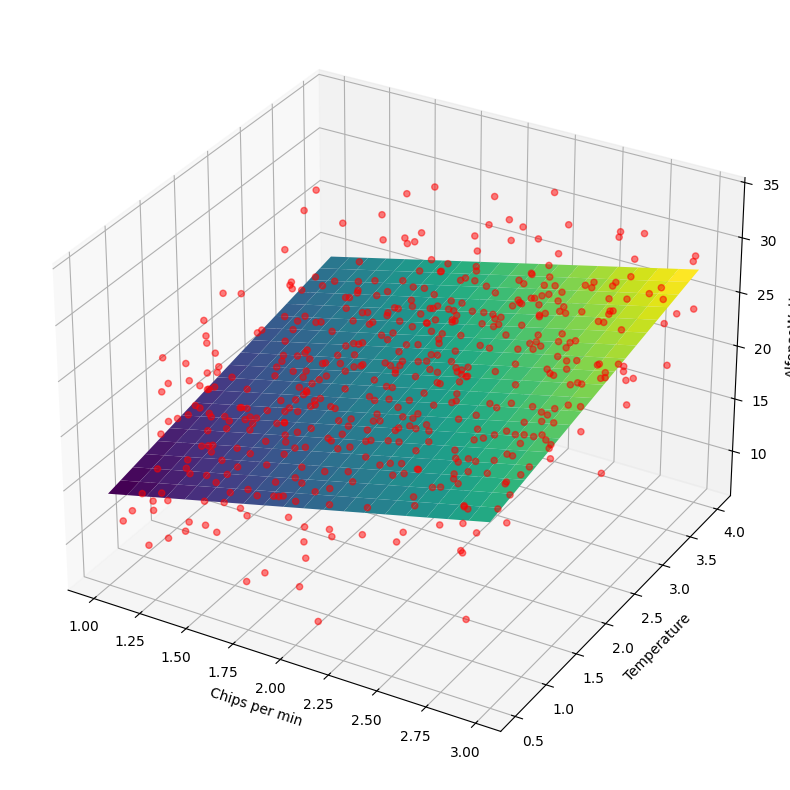

In [ ]:
#Graficando en matplotlib
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(xx, zz, yy, cmap='viridis', alpha=1, label='Plano Best Fit')
ax.scatter(df.chips_per_min, df.temperature, df.alfonsowatts, color='red', alpha=0.5, label='Datos Reales')
ax.set_xlabel('Chips per min')
ax.set_ylabel('Temperature')
ax.set_zlabel('AlfonsoWatts')
plt.show()

In [ ]:
#Graficando en Ploty
fig = go.Figure()
#1. Agregar los puntos (Scatter)
fig.add_trace(go.Scatter3d(
    x=df['chips_per_min'], y=df['temperature'], z=df['alfonsowatts'],
    mode='markers', marker=dict(size=4, color='red', opacity=0.5), name='Datos'
))
# 2. Agregar el plano (Surface)
fig.add_trace(go.Surface(
    x=xx, y=zz, z=yy,
    colorscale='Viridis', opacity=0.7, name='Plano de Ajuste'
))
fig.update_layout(scene=dict(
    xaxis_title='Chips', yaxis_title='Temp', zaxis_title='Watts'
))
fig.show()

### Solution with Gradient Descent for Squared Loss

